# GTSRB — Baseline vs Virtual Adversarial Training
Dataset: German Traffic Sign Recognition Benchmark (Kaggle)  
Architectures: **FCN** (fully connected) and **SmallCNN** (VGG-style)  
Modes: **baseline** (supervised cross-entropy) and **vat** (+ VAT regularisation)  

Change `Config` fields in the experiment cells — all training logic is shared.

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | scikit-learn imported | device: {DEVICE}')

PyTorch 2.11.0+cu128 | scikit-learn imported | device: cuda


## Config

In [2]:
@dataclass
class Config:
    """
    Configuration container for dataset, model, and training parameters.
    """
    # ── Dataset ────────────────────────────────────────────────────────
    dataset_type: str       = 'images'  # updated to use the image generator
    n_samples: int          = 1000      # 1000 images total
    img_size: int           = 48        # Image height and width in pixels
    labeled_fraction: float = 0.1       # 1.0 = fully supervised, 0.0 = unsupervised

    # ── Input / output ─────────────────────────────────────────────────
    num_classes: int        = 2         # Circles (0) and Moons (1)

    # Model
    model_type: str   = 'SmallCNN'      # 'FCN' | 'SmallCNN'
    dropout: float    = 0.5

    # Training
    mode: str         = 'baseline'
    batch_size: int   = 128
    epochs: int       = 20
    lr: float         = 1e-3
    weight_decay: float = 1e-4
    val_fraction: float = 0.15
    patience: int     = 15

    # VAT
    vat_eps: float    = 0.5
    vat_xi: float     = 1e-6
    vat_num_iters: int = 1
    vat_alpha: float  = 1.0

    # Misc
    seed: int         = 42
    num_workers: int  = 0

print(Config())

Config(dataset_type='images', n_samples=1000, img_size=48, labeled_fraction=0.1, num_classes=2, model_type='SmallCNN', dropout=0.5, mode='baseline', batch_size=128, epochs=20, lr=0.001, weight_decay=0.0001, val_fraction=0.15, patience=15, vat_eps=0.5, vat_xi=1e-06, vat_num_iters=1, vat_alpha=1.0, seed=42, num_workers=0)


## Model Architectures

In [3]:
class FCN(nn.Module):
    """
    Two-hidden-layer fully connected network.
    Transforms the multi-dimensional image array into a flat vector before processing.
    """
    def __init__(self, in_features: int, num_classes: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 1200), nn.BatchNorm1d(1200), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1200, 1200),        nn.BatchNorm1d(1200), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1200, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Executes the forward pass of the fully connected network.
        """
        return self.net(x)


class SmallCNN(nn.Module):
    """
    Small convolutional neural network for image classification.
    Processes images through 3 convolutional blocks followed by a fully connected classifier.
    Expects input dimensions of (Batch, 3, 48, 48).
    """
    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Executes the forward pass by routing input through feature extractors,
        then the classifier.
        """
        return self.classifier(self.features(x))


def build_model(cfg: Config) -> nn.Module:
    """
    Instantiates the selected model architecture based on the configuration.
    Calculates total image pixels for the FCN requirement.
    """
    if cfg.model_type == 'FCN':
        in_features = 3 * cfg.img_size * cfg.img_size
        return FCN(in_features, cfg.num_classes, cfg.dropout)
    elif cfg.model_type == 'SmallCNN':
        return SmallCNN(cfg.num_classes, cfg.dropout)
    else:
        raise ValueError(f'Unknown model_type: {cfg.model_type}')

# Smoke test
for mt in ('FCN', 'SmallCNN'):
    cfg_tmp = Config(model_type=mt)
    m   = build_model(cfg_tmp)
    out = m(torch.randn(4, 3, 48, 48))
    p   = sum(x.numel() for x in m.parameters())
    print(f'  {mt:10}  out={tuple(out.shape)}  params={p:,}')

  FCN         out=(4, 2)  params=9,744,002
  SmallCNN    out=(4, 2)  params=2,649,762


## Data Loading

In [4]:
from PIL import Image, ImageDraw

SENTINEL = -1

class SemiSupervisedDataset(Dataset):
    """
    Standard dataset wrapper for tensors.
    Labels with value -1 mark unlabelled samples.
    """
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Retrieves a single sample and its label at the specified index.
        """
        return self.X[idx], self.y[idx]

def generate_image_dataset(n_samples: int, img_size: int, seed: int):
    """
    Generates a synthetic dataset of moon and circle images.
    Returns the images normalized to [0, 1] as a float32 tensor, and labels as a long tensor.
    """
    rng = np.random.default_rng(seed)
    images = []
    labels = []

    half_samples = n_samples // 2

    for _ in range(n_samples):
        # 0 for Circle, 1 for Moon
        label = 0 if len(labels) < half_samples else 1

        # Create a black background image
        img = Image.new('RGB', (img_size, img_size), color='black')
        draw = ImageDraw.Draw(img)

        # Randomize position and size
        radius = rng.integers(8, 16)
        max_coord = img_size - (radius * 2)
        x_pos = rng.integers(0, max_coord)
        y_pos = rng.integers(0, max_coord)

        # Draw base white circle
        bounding_box = [x_pos, y_pos, x_pos + radius * 2, y_pos + radius * 2]
        draw.ellipse(bounding_box, fill='white')

        if label == 1:
            # Draw an overlapping black circle to create a crescent moon shape
            offset_x = rng.integers(2, 6)
            offset_y = rng.integers(2, 6)
            mask_box = [x_pos + offset_x, y_pos + offset_y,
                        x_pos + radius * 2 + offset_x, y_pos + radius * 2 + offset_y]
            draw.ellipse(mask_box, fill='black')

        # Convert to numpy and rearrange dimensions to (Channels, Height, Width)
        img_array = np.array(img).transpose((2, 0, 1))
        images.append(img_array)
        labels.append(label)

    # Shuffle the dataset
    images = np.array(images)
    labels = np.array(labels)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    # Normalize pixel values between 0 and 1
    images = images[indices].astype(np.float32) / 255.0
    labels = labels[indices].astype(np.int64)

    return images, labels

def get_loaders(cfg: Config):
    """
    Prepares the training, validation, and test data loaders.
    Applies the specified fraction of labels to the training set.
    """
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    # 1. Generate Image Data
    X, y = generate_image_dataset(cfg.n_samples, cfg.img_size, cfg.seed)

    # 2. Split data (70% train, 15% validation, 15% test)
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=cfg.seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=cfg.seed, stratify=y_tmp
    )

    # 3. Mask labels for semi-supervised learning
    rng = np.random.default_rng(cfg.seed)
    n_labelled = max(cfg.num_classes, int(len(y_train) * cfg.labeled_fraction))
    idx = np.arange(len(y_train))
    rng.shuffle(idx)

    y_semi = np.full_like(y_train, SENTINEL)
    y_semi[idx[:n_labelled]] = y_train[idx[:n_labelled]]

    n_unlabelled = (y_semi == SENTINEL).sum()
    print(f'  Generated {cfg.n_samples} Images '
          f'train={len(y_train)} '
          f'(labelled={n_labelled}, unlabelled={n_unlabelled})  '
          f'val={len(y_val)}  test={len(y_test)}')

    # 4. Convert to PyTorch tensors and DataLoaders
    X_tr, y_tr = torch.tensor(X_train), torch.tensor(y_semi)
    X_vl, y_vl = torch.tensor(X_val),   torch.tensor(y_val)
    X_ts, y_ts = torch.tensor(X_test),  torch.tensor(y_test)

    kw = dict(batch_size=cfg.batch_size)
    train_loader = DataLoader(SemiSupervisedDataset(X_tr, y_tr), shuffle=True, drop_last=True, **kw)
    val_loader   = DataLoader(SemiSupervisedDataset(X_vl, y_vl), shuffle=False, **kw)
    test_loader  = DataLoader(SemiSupervisedDataset(X_ts, y_ts), shuffle=False, **kw)

    return train_loader, val_loader, test_loader

## VAT Loss

In [5]:
def _l2_normalize(t: torch.Tensor) -> torch.Tensor:
    """Unit-L2-normalise each sample in the batch."""
    flat = t.view(t.size(0), -1)
    norm = flat.norm(p=2, dim=1, keepdim=True).clamp(min=1e-8)
    return (flat / norm).view_as(t)


def vat_loss(model: nn.Module, x: torch.Tensor,
             eps: float = 1.0, xi: float = 1e-6, num_iters: int = 1) -> torch.Tensor:
    """
    Virtual Adversarial Training regularisation loss.
    Miyato et al., 'Virtual Adversarial Training', TPAMI 2019.

    Returns  KL( p(y|x; theta) || p(y|x+r_adv; theta) )
    where r_adv is the worst-case L2-bounded perturbation found via
    power iteration (num_iters=1 is standard and sufficient in practice).
    """
    # Clean distribution — treated as a fixed target, no gradient
    with torch.no_grad():
        p_clean = F.softmax(model(x), dim=1)

    # Random unit-norm starting direction
    d = _l2_normalize(torch.randn_like(x))

    # Power iteration: find direction that maximises KL divergence
    for _ in range(num_iters):
        d = d.detach().requires_grad_(True)
        kl = F.kl_div(
            F.log_softmax(model(x + xi * d), dim=1),
            p_clean, reduction='batchmean'
        )
        # Gradient only w.r.t. d — model-param gradients are NOT accumulated here
        (grad_d,) = torch.autograd.grad(kl, d)
        d = _l2_normalize(grad_d.detach())

    # Final VAT loss — gradient flows to model params via this forward pass
    x_adv = (x + eps * d).detach()
    return F.kl_div(
        F.log_softmax(model(x_adv), dim=1),
        p_clean.detach(), reduction='batchmean'
    )

## Trainer
A single `train()` function handles both modes — switch `cfg.mode` to change behaviour.

In [6]:
def _train_epoch(model, loader, criterion, optimizer, cfg: Config):
    """
    Executes one complete training pass over the provided dataset.
    Updates model parameters based on the calculated loss.
    Displays a text-based progress bar in the console.
    """
    model.train()
    total_loss = total_acc = 0.0
    n = len(loader)

    for i, (x, y) in enumerate(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)

        # Semi-supervised: cross-entropy only on labelled samples
        labelled = (y != SENTINEL)
        if labelled.any():
            loss = criterion(logits[labelled], y[labelled])
        else:
            loss = torch.zeros(1, device=DEVICE, requires_grad=True)

        if cfg.mode == 'vat':
            loss = loss + cfg.vat_alpha * vat_loss(
                model, x, eps=cfg.vat_eps, xi=cfg.vat_xi, num_iters=cfg.vat_num_iters
            )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        # Accuracy tracked only on labelled portion
        if labelled.any():
            total_acc += (logits[labelled].argmax(1) == y[labelled]).float().mean().item()

        # Calculates the percentage of completion for the current epoch.
        progress = (i + 1) / n

        # Determines the number of filled blocks in a 30-character wide bar.
        filled_length = int(30 * progress)

        # Constructs the visual string for the progress bar.
        bar = '=' * filled_length + '-' * (30 - filled_length)

        # Outputs the bar to the console.
        # The \r character overwrites the previous line.
        print(f'\r  Step {i + 1:>3}/{n} [{bar}] Loss: {loss.item():.4f}', end='', flush=True)

    # Clears the progress bar line after the epoch completes to preserve table formatting.
    print('\r' + ' ' * 70 + '\r', end='', flush=True)

    return total_loss / n, total_acc / n


@torch.no_grad()
def _evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_acc = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits      = model(x)
        total_loss += criterion(logits, y).item()
        total_acc  += (logits.argmax(1) == y).float().mean().item()
    n = len(loader)
    return total_loss / n, total_acc / n


def train(cfg: Config):
    """Train for one Config; return (history dict, final metrics dict)."""
    torch.manual_seed(cfg.seed)

    train_loader, val_loader, test_loader = get_loaders(cfg)
    model     = build_model(cfg).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.lr * 1e-2)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state   = None
    no_improve   = 0

    label = f'[{cfg.mode.upper()}] {cfg.model_type} | GTSRB'
    print(f'\n{"="*60}\n  {label}\n{"="*60}')
    print(f'  {"Ep":>3} | {"TrLoss":>8} {"TrAcc":>7} | {"VlLoss":>8} {"VlAcc":>7} |')
    print(f'  {"-"*50}')

    for epoch in range(1, cfg.epochs + 1):
        tr_l, tr_a = _train_epoch(model, train_loader, criterion, optimizer, cfg)
        vl_l, vl_a = _evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_l)
        history['train_acc'].append(tr_a)
        history['val_loss'].append(vl_l)
        history['val_acc'].append(vl_a)

        tag = ''
        if vl_a > best_val_acc:
            best_val_acc = vl_a
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
            tag = ' *'
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1 or tag:
            print(f'  {epoch:>3} | {tr_l:>8.4f} {tr_a*100:>6.2f}% | {vl_l:>8.4f} {vl_a*100:>6.2f}% |{tag}')

        if no_improve >= cfg.patience:
            print(f'\n  Early stop at epoch {epoch} (no val gain for {cfg.patience} epochs)')
            break

    model.load_state_dict(best_state)
    ts_l, ts_a = _evaluate(model, test_loader, criterion)
    print(f'\n  Best Val Acc : {best_val_acc*100:.2f}%')
    print(f'  Test Acc     : {ts_a*100:.2f}%  |  Test Loss: {ts_l:.4f}')

    return history, {'val_acc': best_val_acc, 'test_acc': ts_a, 'test_loss': ts_l}

## Experiments
Four runs: FCN and SmallCNN, each in baseline and VAT modes.  
Adjust any `Config` field (e.g. `vat_eps`, `vat_alpha`, `epochs`) to explore hyperparameters.

In [7]:
import pickle

# Defines the subset of training data fractions to be evaluated.
FRACTIONS = [0.0, 0.25, 0.5, 1.0]

# Initializes a dictionary to store performance metrics for each data fraction and model configuration.
sweep = {}

# Defines the combinations of neural network architectures and training modes to evaluate.
# VAT (Virtual Adversarial Training) is a regularization technique that works without labels.
# Baseline refers to standard supervised training, which requires labels to function.
RUNS = [
    ('FCN',      'vat'),       # VAT can run at frac=0.0 (pure unsupervised)
    ('FCN',      'baseline'),  # baseline skips frac=0.0 — no CE signal
    ('SmallCNN', 'vat'),
    ('SmallCNN', 'baseline'),
]

# Iterates over each defined data fraction to conduct training experiments.
for frac in FRACTIONS:
    print(f'\n{"#"*60}')
    print(f'  labeled_fraction = {frac:.0%}')
    print(f'{"#"*60}')
    sweep.setdefault(frac, {})

    # Iterates over each model architecture and training mode combination.
    for model_type, mode in RUNS:
        if mode == 'baseline' and frac == 0.0:
            continue                          # baseline undefined with zero labels

        # Determines the text description for the current data fraction.
        if frac == 0.0:
            fraction_text = "no labelled data"
        elif frac == 1.0:
            fraction_text = "fully labelled data"
        else:
            fraction_text = f"{frac:.0%} partially labelled data"

        # Outputs the current experiment configuration to the console.
        print(f"  -> Model: {model_type} | Mode: {mode} | Fraction: {fraction_text}")

        key = f'{model_type} / {mode}'

        # Executes the training process and stores both the history and metrics in a nested dictionary.
        hist, m = train(Config(model_type=model_type, mode=mode, labeled_fraction=frac))
        sweep[frac][key] = {'history': hist, 'metrics': m}

# Serializes the dictionary and writes it to a binary file.
# The 'wb' flag opens the file in write-binary mode.
with open('NoteBook_Artificial_Data.pkl', 'wb') as file:
    pickle.dump(sweep, file)

print("\nTraining complete. Data saved to NoteBook_Artificial_Data.pkl")


############################################################
  labeled_fraction = 0%
############################################################
  -> Model: FCN | Mode: vat | Fraction: no labelled data
  Generated 1000 Images train=700 (labelled=2, unlabelled=698)  val=150  test=150

  [VAT] FCN | GTSRB
   Ep |   TrLoss   TrAcc |   VlLoss   VlAcc |
  --------------------------------------------------
    1 |   0.2431   0.00% |   1.4412  18.08% | *                       
    2 |   0.3093  20.00% |   1.1835  47.02% | *                       
    3 |   0.1008  20.00% |   1.4033  53.59% | *                       
    4 |   0.1284  40.00% |   1.5566  65.80% | *                       
    6 |   0.0690  20.00% |   1.4488  66.51% | *                       
    7 |   0.2890  20.00% |   1.3766  67.68% | *                       
   10 |   0.0975  40.00% |   1.3295  60.80% |                         
   20 |   0.0944  40.00% |   1.0654  62.29% |                         

  Best Val Acc : 67.68%
 

## Results

Data successfully loaded from sweep_data.pkl


           Labeled %     FCN / vatFCN / baselineSmallCNN / vatSmallCNN / baseline
  --------------------------------------------------------------------------
        unsupervised         0.39%           n/a         2.77%           n/a
          25% labels         2.35%         2.69%         1.08%         1.95%
          50% labels         3.05%         4.33%         4.05%         4.08%
    fully supervised         4.41%         3.91%         5.00%         5.54%



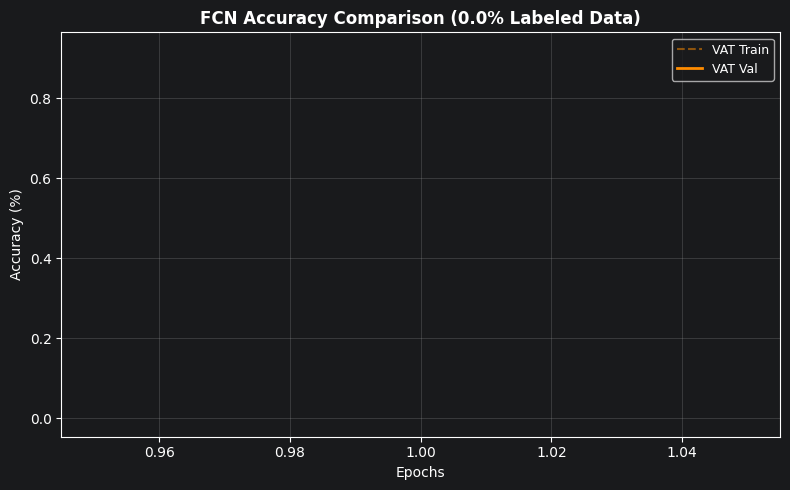

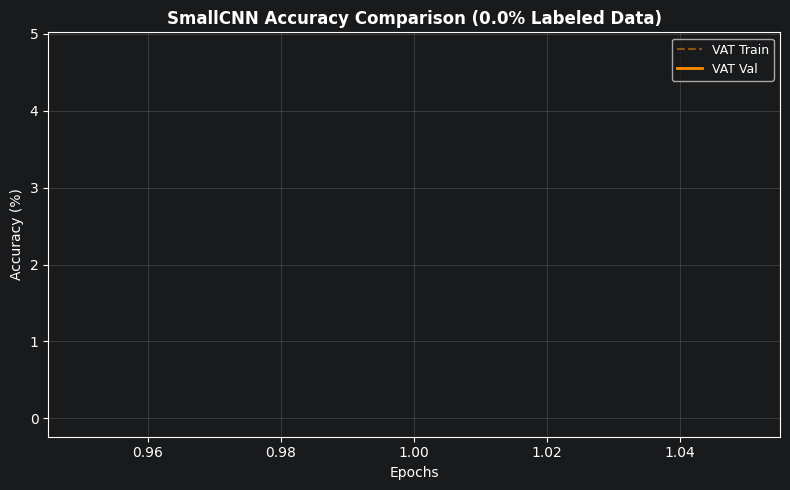

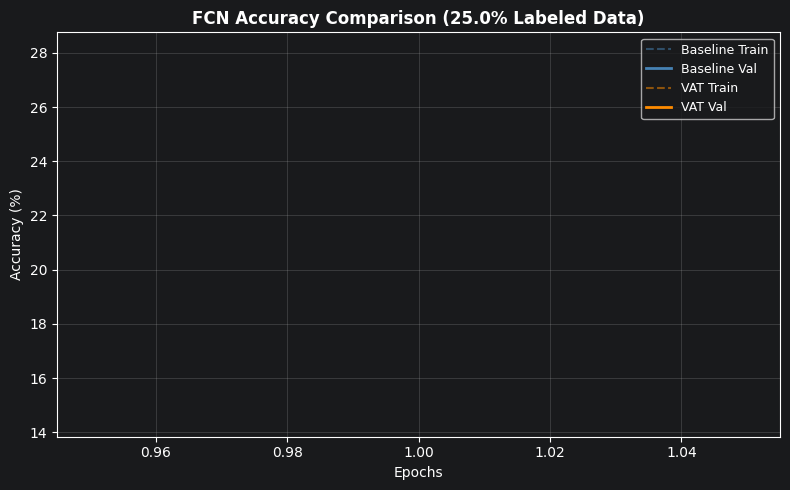

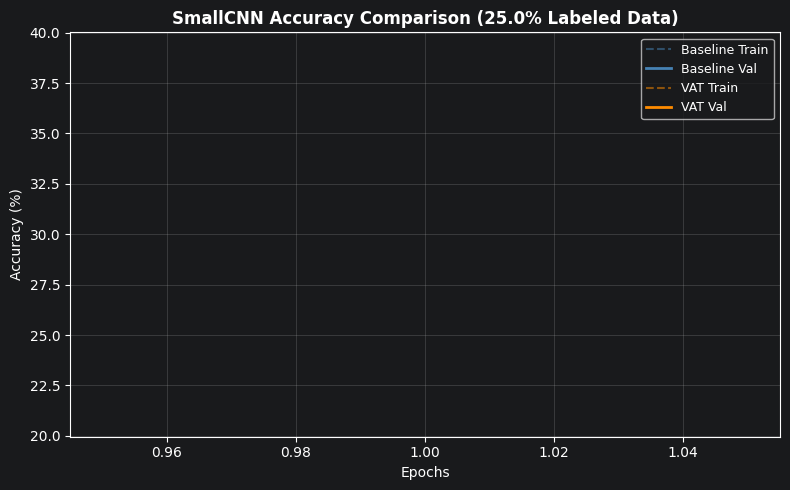

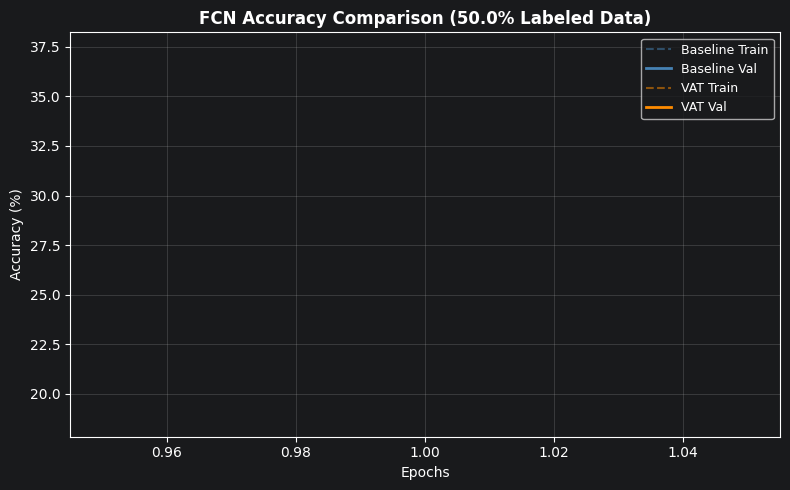

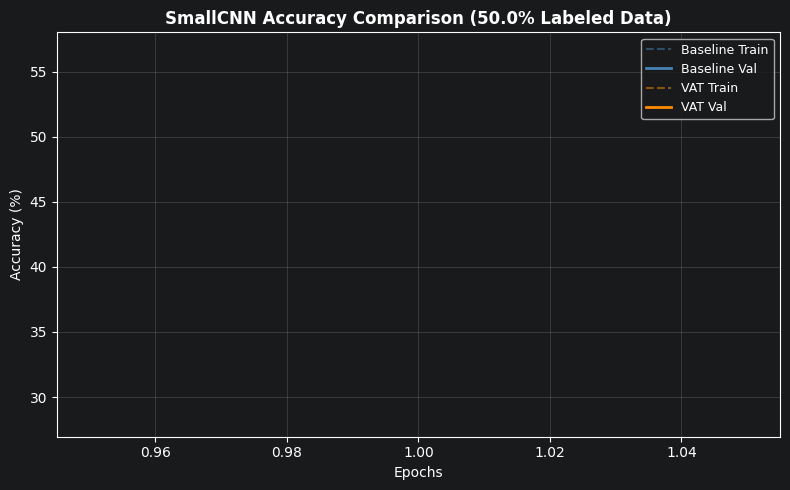

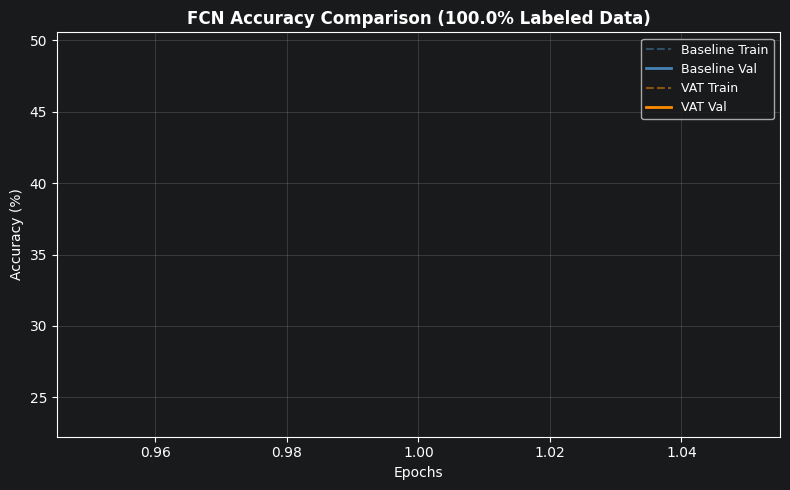

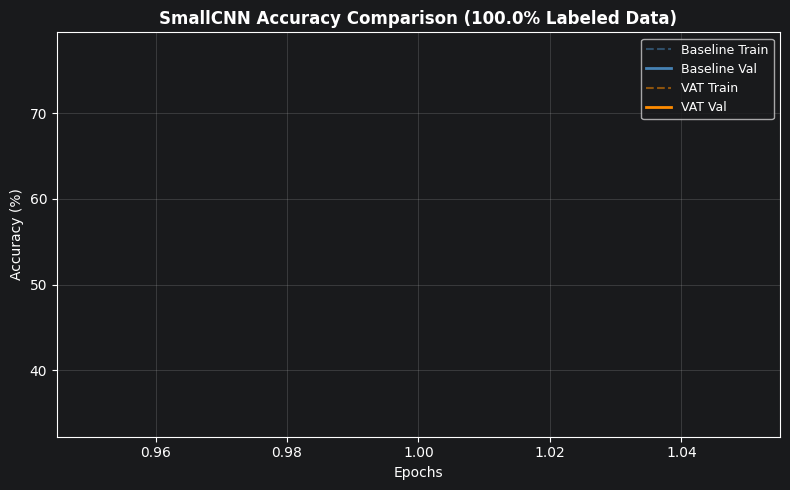

In [1]:
import matplotlib.pyplot as plt
import pickle
import os

# Deserializes the dictionary from the binary file if it is not already loaded in memory.
# The 'rb' flag opens the file in read-binary mode.
if 'sweep' not in locals():
    if os.path.exists('NoteBook_Artificial_Data.pkl'):
        with open('NoteBook_Artificial_Data.pkl', 'rb') as file:
            sweep = pickle.load(file)
        print("Data successfully loaded from sweep_data.pkl\n")
    else:
        raise FileNotFoundError("The file sweep_data.pkl does not exist. Run the training script first.")


# ── Summary table ─────────────────────────────────────────────────────
KEYS = ['FCN / vat', 'FCN / baseline', 'SmallCNN / vat', 'SmallCNN / baseline']

col_w = 14
header = f'  {"Labeled %":>18}' + ''.join(f'{k:>{col_w}}' for k in KEYS)
print(f'\n{"="*(20 + col_w * len(KEYS))}')
print(header)
print(f'  {"-"*(18 + col_w * len(KEYS))}')
for frac, modes in sweep.items():
    label = ('unsupervised'   if frac == 0.0 else
             'fully supervised' if frac == 1.0 else
             f'{frac:.0%} labels')
    row = f'  {label:>18}'
    for k in KEYS:
        acc = f'{modes[k]["metrics"]["test_acc"]*100:.2f}%' if k in modes else 'n/a'
        row += f'{acc:>{col_w}}'
    print(row)
print(f'{"="*(20 + col_w * len(KEYS))}\n')


# ── Individual Accuracy per Epoch Plots ───────────────────────────────

def plot_accuracy_comparison(fraction: float, model_type: str, baseline_history: dict, vat_history: dict):
    """
    Creates a single line chart comparing the accuracy of a Baseline model and a VAT model.
    The chart places epochs on the X-axis and accuracy percentage on the Y-axis.
    Solid lines represent validation accuracy. Dashed lines represent training accuracy.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    title = f'{model_type} Accuracy Comparison ({fraction * 100}% Labeled Data)'
    ax.set_title(title, fontweight='bold')

    # Plots Baseline data if the history is provided.
    if baseline_history:
        epochs_base = range(1, len(baseline_history['train_acc']) + 1)
        ax.plot(epochs_base, [v * 100 for v in baseline_history['train_acc']],
                '--', color='steelblue', alpha=0.5, label='Baseline Train')
        ax.plot(epochs_base, [v * 100 for v in baseline_history['val_acc']],
                '-', color='steelblue', linewidth=2, label='Baseline Val')

    # Plots VAT data if the history is provided.
    if vat_history:
        epochs_vat = range(1, len(vat_history['train_acc']) + 1)
        ax.plot(epochs_vat, [v * 100 for v in vat_history['train_acc']],
                '--', color='darkorange', alpha=0.5, label='VAT Train')
        ax.plot(epochs_vat, [v * 100 for v in vat_history['val_acc']],
                '-', color='darkorange', linewidth=2, label='VAT Val')

    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def generate_all_plots(fractions: list, model_types: list, sweep_data: dict):
    """
    Iterates through all provided data fractions and model types to generate individual plots.
    Retrieves the training history from the nested sweep_data dictionary.
    """
    for frac in fractions:
        for model in model_types:
            key_baseline = f'{model} / baseline'
            key_vat = f'{model} / vat'

            base_data = sweep_data.get(frac, {}).get(key_baseline, {})
            vat_data = sweep_data.get(frac, {}).get(key_vat, {})

            hist_base = base_data.get('history')
            hist_vat = vat_data.get('history')

            if hist_base or hist_vat:
                plot_accuracy_comparison(frac, model, hist_base, hist_vat)

# Defines the models and fractions based on the initial configuration.
model_types = ['FCN', 'SmallCNN']
FRACTIONS = [0.0, 0.25, 0.5, 1.0]

# Executes the plotting sequence.
generate_all_plots(FRACTIONS, model_types, sweep)